In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from statsmodels.stats.stattools import durbin_watson
from statsmodels.tsa.stattools import adfuller
from statsmodels.stats.diagnostic import acorr_ljungbox

plt.rcParams['figure.figsize'] = (12, 5)
sns.set_theme(style="whitegrid")

In [ ]:
odgovori_3_1 = """
ODGOVORI - 3.1 VALIDACIJA NA SPLOŠNO
======================================

KAJ JE VALIDACIJA?
Validacija je sistematičen proces preverjanja ali model:
- Deluje tako kot je bil zasnovan
- Je primeren za namen uporabe
- Ostaja zanesljiv skozi čas
V bančništvu je validacija obvezna zahteva regulatorjev (ECB, Banka Slovenije).

KLJUČNI KORAKI VALIDACIJE:

1. KONCEPTUALNI PREGLED
   - Preverimo teoretično utemeljenost modela
   - Ali so spremenljivke ekonomsko smiselne?
   - Ali so predznaki koeficientov pravilni?
   - Ali je metodologija ustrezna?

2. STATISTIČNI PREGLED
   - Preverimo statistično značilnost koeficientov (p-vrednosti)
   - Ocenimo prileganje modela (R-squared, AIC, BIC)
   - Preverimo predpostavke modela (normalnost, homoskedastičnost)
   - Testiramo ostanke modela

3. PREVERITEV NAPOVEDNE MOČI
   - Kako dobro model napove na novih podatkih?
   - Merimo z ustreznimi metrikami (AUC, Gini, KS statistika)
   - Primerjamo napovedi z dejanskimi vrednostmi

4. STABILNOSTNI PREGLED
   - Ali model deluje enako dobro v različnih obdobjih?
   - Ali deluje enako v različnih segmentih?

5. DOKUMENTACIJA IN MNENJE
   - Dokumentiramo ugotovitve
   - Podamo mnenje: pozitivno / s pridržkom / negativno
   - Predlagamo morebitne izboljšave
"""

print(odgovori_3_1)


ODGOVORI - 3.1 VALIDACIJA NA SPLOŠNO

KAJ JE VALIDACIJA?
Validacija je sistematičen proces preverjanja ali model:
- Deluje tako kot je bil zasnovan
- Je primeren za namen uporabe
- Ostaja zanesljiv skozi čas
V bančništvu je validacija obvezna zahteva regulatorjev (ECB, Banka Slovenije).

KLJUČNI KORAKI VALIDACIJE:

1. KONCEPTUALNI PREGLED
   - Preverimo teoretično utemeljenost modela
   - Ali so spremenljivke ekonomsko smiselne?
   - Ali so predznaki koeficientov pravilni?
   - Ali je metodologija ustrezna?

2. STATISTIČNI PREGLED
   - Preverimo statistično značilnost koeficientov (p-vrednosti)
   - Ocenimo prileganje modela (R-squared, AIC, BIC)
   - Preverimo predpostavke modela (normalnost, homoskedastičnost)
   - Testiramo ostanke modela

3. PREVERITEV NAPOVEDNE MOČI
   - Kako dobro model napove na novih podatkih?
   - Merimo z ustreznimi metrikami (AUC, Gini, KS statistika)
   - Primerjamo napovedi z dejanskimi vrednostmi

4. STABILNOSTNI PREGLED
   - Ali model deluje enako dobro

In [5]:
# Uvoz podatkov
ostanki = pd.read_excel('Ostanki_modela.xlsx')
podatki = pd.read_excel('Podatki.xlsx')


In [6]:
print("=== OSTANKI MODELA ===")
print(f"Velikost: {ostanki.shape}")
ostanki.head()

=== OSTANKI MODELA ===
Velikost: (43, 1)


,model residuals
0,0.144287
1,0.346838
2,-0.205528
3,0.290501
4,-0.121948


In [9]:
print("=== PODATKI ===")
print(f"Velikost: {podatki.shape}")
podatki.head()

=== PODATKI ===
Velikost: (48, 6)


,kvartal,PD,CPI,GDP,EUR6M,U
0,2008_1Q,3.027668,1.401300,1.6,4.725,5.1
1,2008_2Q,2.146360,2.825979,1.6,5.130,4.2
2,2008_3Q,2.975124,-0.699400,-0.5,5.377,4.1
3,2008_4Q,3.002496,-1.295800,-3.7,2.971,4.3
4,2009_1Q,3.510041,0.997475,-4.4,1.670,5.4


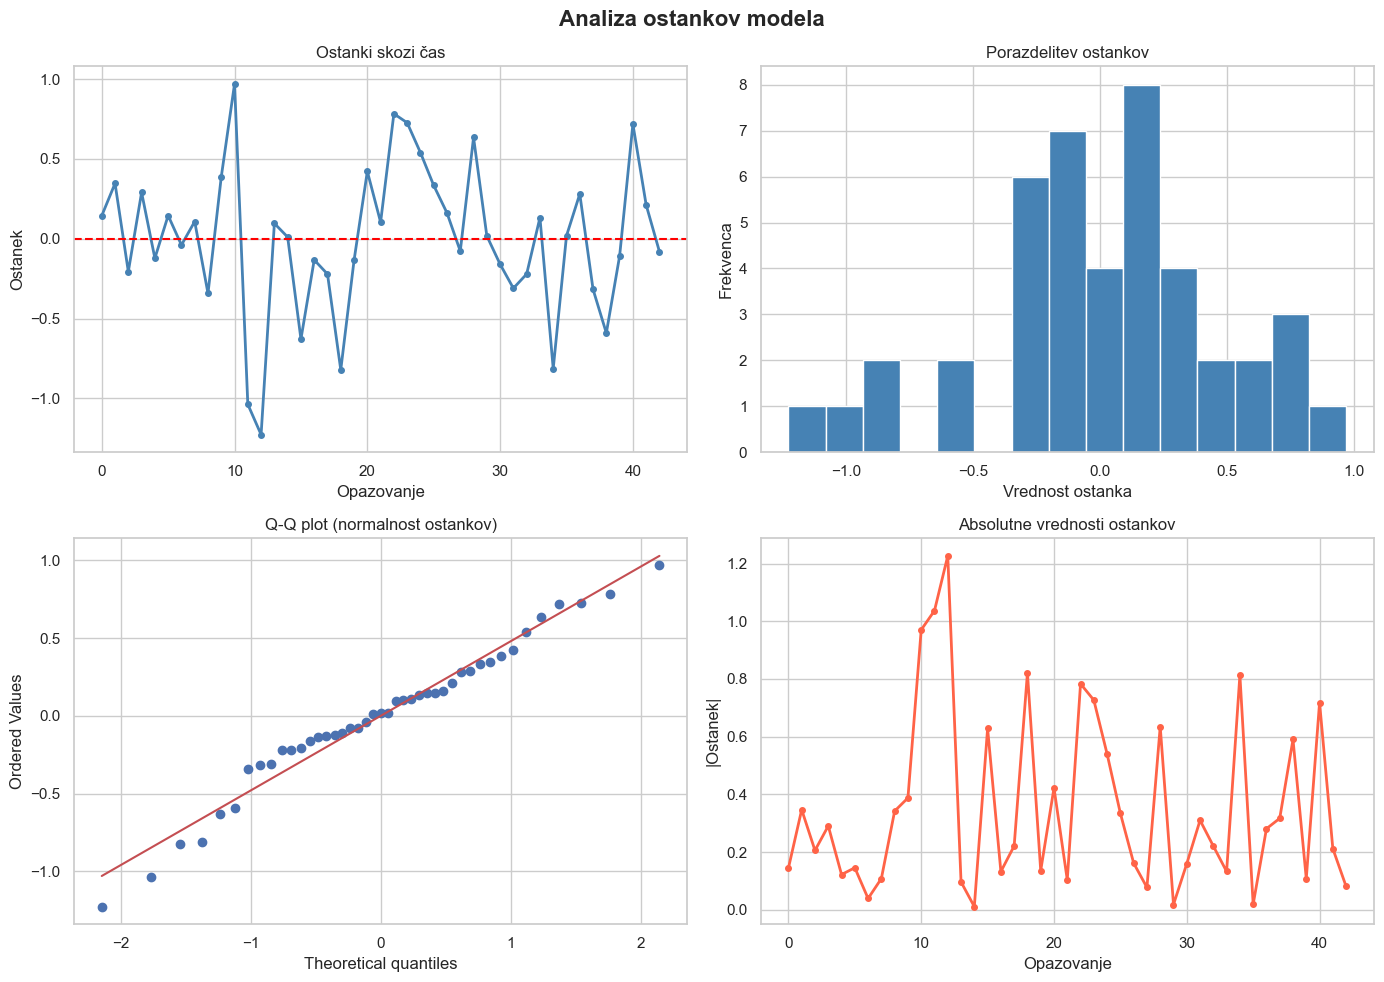

In [12]:
# Preimenovanje stolpca
ostanki.columns = ['ostanki']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Analiza ostankov modela', fontsize=16, fontweight='bold')

# Graf 1: Ostanki skozi čas
axes[0,0].plot(ostanki['ostanki'], color='steelblue', linewidth=2, marker='o', markersize=4)
axes[0,0].axhline(y=0, color='red', linestyle='--', linewidth=1.5)
axes[0,0].set_title('Ostanki skozi čas')
axes[0,0].set_xlabel('Opazovanje')
axes[0,0].set_ylabel('Ostanek')

# Graf 2: Histogram ostankov
axes[0,1].hist(ostanki['ostanki'], bins=15, color='steelblue', edgecolor='white')
axes[0,1].set_title('Porazdelitev ostankov')
axes[0,1].set_xlabel('Vrednost ostanka')
axes[0,1].set_ylabel('Frekvenca')

# Graf 3: Q-Q plot (normalnost)
stats.probplot(ostanki['ostanki'], dist="norm", plot=axes[1,0])
axes[1,0].set_title('Q-Q plot (normalnost ostankov)')

# Graf 4: Absolutne vrednosti ostankov (heteroskedastičnost)
axes[1,1].plot(np.abs(ostanki['ostanki']), color='tomato', linewidth=2, marker='o', markersize=4)
axes[1,1].set_title('Absolutne vrednosti ostankov')
axes[1,1].set_xlabel('Opazovanje')
axes[1,1].set_ylabel('|Ostanek|')

plt.tight_layout()
plt.savefig('analiza_ostankov.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# Test 1: Shapiro-Wilk (normalnost)
stat_sw, p_sw = stats.shapiro(ostanki['ostanki'])
print("=== TEST NORMALNOSTI (Shapiro-Wilk) ===")
print(f"Statistika: {stat_sw:.4f}")
print(f"p-vrednost: {p_sw:.4f}")
print(f"Zaključek: {'Ostanki so normalni (p>0.05)' if p_sw > 0.05 else 'Ostanki NISO normalni (p<0.05)'}")

# Test 2: Durbin-Watson (avtokorelacija ostankov)
dw = durbin_watson(ostanki['ostanki'])
print("\n=== TEST AVTOKORELACIJE (Durbin-Watson) ===")
print(f"Statistika: {dw:.4f}")
print(f"Zaključek: {'Ni avtokorelacije (vrednost ~2)' if 1.5 < dw < 2.5 else 'Prisotna avtokorelacija (vrednost daleč od 2)'}")

# Test 3: Ljung-Box (avtokorelacija ostankov)
lb_test = acorr_ljungbox(ostanki['ostanki'], lags=[4, 8], return_df=True)
print("\n=== LJUNG-BOX TEST ===")
print(lb_test)
print(f"Zaključek: {'Ni avtokorelacije' if (lb_test['lb_pvalue'] > 0.05).all() else 'Prisotna avtokorelacija v ostankih'}")

# Test 4: ADF (stacionarnost ostankov)
adf_test = adfuller(ostanki['ostanki'], regression='c')
print("\n=== ADF TEST ===")
print(f"Statistika: {adf_test[0]:.4f}")
print(f"p-vrednost: {adf_test[1]:.4f}")
print(f"Zaključek: {'Ostanki niso stacionarni (p>0.05)' if adf_test[1] > 0.05 else 'Ostanki so stacionarni (p<0.05)'}")

=== TEST NORMALNOSTI (Shapiro-Wilk) ===
Statistika: 0.9734
p-vrednost: 0.4118
Zaključek: Ostanki so normalni (p>0.05)

=== TEST AVTOKORELACIJE (Durbin-Watson) ===
Statistika: 1.5691
Zaključek: Ni avtokorelacije (vrednost ~2)

=== LJUNG-BOX TEST ===
     lb_stat  lb_pvalue
4   6.916485   0.140368
8  10.880662   0.208553
Zaključek: Ni avtokorelacije

=== ADF TEST ===
Statistika: -2.5761
p-vrednost: 0.0980
Zaključek: Ostanki niso stacionarni (p>0.05)


=== PREGLED KOEFICIENTOV MODELA ===
Spremenljivka                             Opis  Koeficient  p_vrednost Statisticno_znacilen
    Konstanta                        Konstanta      1.4584      0.0050                   Da
          PD2        Zamaknjena PD (1 kvartal)      0.3250      0.0102                   Da
       EUR6M0      Euribor 6M (tekoče obdobje)      2.5649      0.0001                   Da
         GDP0             BDP (tekoče obdobje)      0.4243      0.0010                   Da
       EUR6M1     Euribor 6M (1 kvartal nazaj)     -1.6332      0.0148                   Da
       EUR6M5    Euribor 6M (5 kvartali nazaj)      0.1635      0.0694          Ne (p>0.05)
         CPI0   Inflacija CPI (tekoče obdobje)     -0.2624      0.0148                   Da
         CPI5 Inflacija CPI (5 kvartali nazaj)     -0.2325      0.0174                   Da
           U1 Brezposelnost (1 kvartal naprej)     -0.0895      0.0799          Ne (p>0.05)

=== STATISTIČNE METRIKE MODELA ===
Adjusted

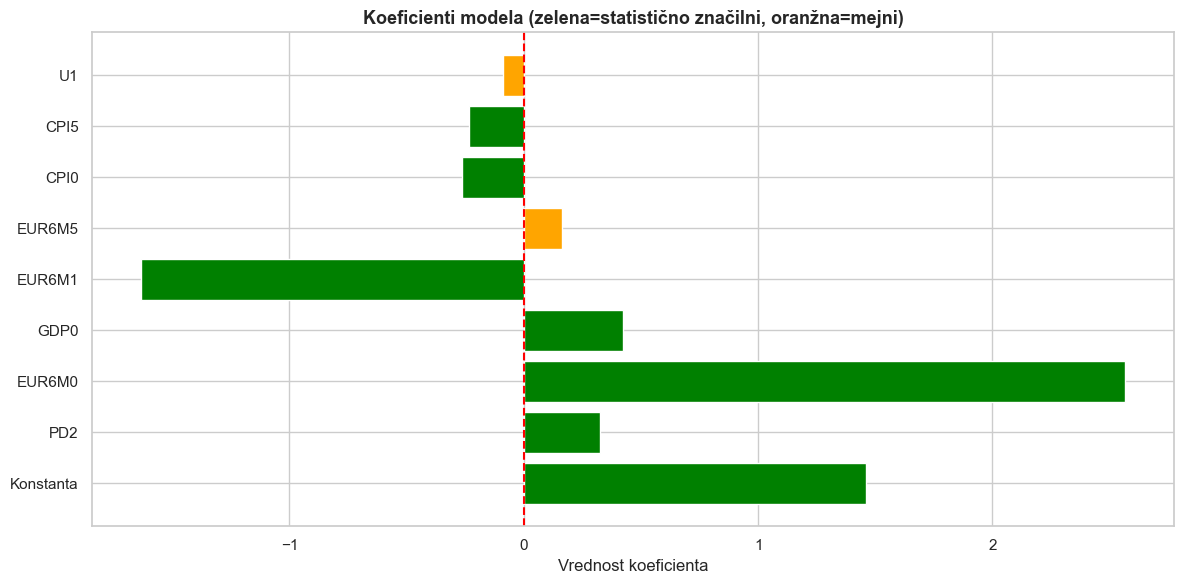

Graf koeficientov shranjen


In [33]:
# Pregled koeficientov modela iz naloge
koeficienti = pd.DataFrame({
    'Spremenljivka': ['Konstanta', 'PD2', 'EUR6M0', 'GDP0', 'EUR6M1', 'EUR6M5', 'CPI0', 'CPI5', 'U1'],
    'Opis': [
        'Konstanta',
        'Zamaknjena PD (1 kvartal)',
        'Euribor 6M (tekoče obdobje)',
        'BDP (tekoče obdobje)',
        'Euribor 6M (1 kvartal nazaj)',
        'Euribor 6M (5 kvartali nazaj)',
        'Inflacija CPI (tekoče obdobje)',
        'Inflacija CPI (5 kvartali nazaj)',
        'Brezposelnost (1 kvartal naprej)'
    ],
    'Koeficient': [1.4584, 0.325, 2.5649, 0.4243, -1.6332, 0.1635, -0.2624, -0.2325, -0.0895],
    'p_vrednost': [0.005, 0.0102, 0.0001, 0.001, 0.0148, 0.0694, 0.0148, 0.0174, 0.0799],
    'Statisticno_znacilen': ['Da', 'Da', 'Da', 'Da', 'Da', 'Ne (p>0.05)', 'Da', 'Da', 'Ne (p>0.05)']
})

print("=== PREGLED KOEFICIENTOV MODELA ===")
print(koeficienti.to_string(index=False))

print("\n=== STATISTIČNE METRIKE MODELA ===")
print(f"Adjusted R²: 0.7784")
print(f"Razlaga: Model pojasni 77.84% variance v PD - dobro prileganje")

# Vizualizacija koeficientov
plt.figure(figsize=(12, 6))
barve = ['green' if p < 0.05 else 'orange' for p in koeficienti['p_vrednost']]
plt.barh(koeficienti['Spremenljivka'], koeficienti['Koeficient'], color=barve)
plt.axvline(x=0, color='red', linestyle='--', linewidth=1.5)
plt.title('Koeficienti modela (zelena=statistično značilni, oranžna=mejni)', 
          fontsize=13, fontweight='bold')
plt.xlabel('Vrednost koeficienta')
plt.tight_layout()
plt.savefig('koeficienti_modela.png', dpi=150, bbox_inches='tight')
plt.show()
print("Graf koeficientov shranjen")

In [ ]:
mnenje_3_2 = """
VALIDACIJSKO MNENJE - 3.2 KONCEPTUALNI PREGLED
================================================

1. STATISTIČNE METRIKE
-----------------------
POZITIVNO:
- Adjusted R² = 0.7784 - model pojasni 78% variance PD (dobro)
- Večina koeficientov statistično značilnih (p < 0.05)
- Ostanki so normalno porazdeljeni (Shapiro-Wilk p=0.41)
- Ni avtokorelacije v ostankih (Ljung-Box p>0.05)
- Durbin-Watson = 1.57 (blizu 2, sprejemljivo)

POMANJKLJIVOSTI:
- EUR6M5 (p=0.0694) - ni statistično značilen na nivoju 5%
- U1 (p=0.0799) - ni statistično značilen na nivoju 5%
   → Obe spremenljivki bi morali preveriti ali jih obdržimo v modelu
- Durbin-Watson = 1.57 - rahlo pod idealno vrednostjo 2.0
   → Možna šibka pozitivna avtokorelacija ostankov
-  Majhen vzorec (43 opazovanj) - omejuje zanesljivost ocen
- Ostanki niso stacionarni (predvsem zaradi napak pri 9-12 indeksu)

2. SMISELNOST KOEFICIENTOV
---------------------------
PD2 (0.325): Pozitiven - višja pretekla PD → višja trenutna PD. 
   Ekonomsko logično (vztrajnost neplačil).

GDP0 (0.424): Pozitiven - PRESENETLJIVO
   Pričakovali bi negativen predznak (višji BDP → manj neplačil).
   (-) Možna multikolinearnost z drugimi spremenljivkami!

EUR6M0 (2.565): Pozitiven - višji Euribor → višja PD. 
   Ekonomsko logično (dražji krediti → več neplačil).

EUR6M1 (-1.633): Negativen - zamaknjeni Euribor zmanjša PD.
   Skupaj z EUR6M0 kaže kompleksen zamaknjeni učinek obrestnih mer.
   (-) Prisotnost EUR6M0 in EUR6M1 hkrati nakazuje multikolinearnost!

CPI0 (-0.262) in CPI5 (-0.233): Negativna - višja inflacija → 
   nižja PD. Ekonomsko logično (inflacija zmanjša realno vrednost 
   dolga → lažje odplačevanje).

(-) U1 (-0.090): Negativen - višja brezposelnost → nižja PD?
   TO NI EKONOMSKO LOGIČNO! Pričakujemo pozitiven predznak.
   Možna razlaga: multikolinearnost z drugimi spremenljivkami.

3. SKUPNA OCENA MODELA
-----------------------
OCENA: S PRIDRŽKOM

Utemeljitev:
+ Model ima dobro statistično prileganje (R²=0.78)
+ Večina koeficientov je statistično značilnih
+ Ostanki zadostijo statističnim predpostavkam
- Visok R² je lahko posledica vecjega stevila spremenljivk
- Koeficient U1 ima napačen predznak (ekonomsko nesmiselno)
- GDP0 ima pozitiven predznak - vprašljivo ekonomsko
- EUR6M0 in EUR6M1 skupaj kažeta na multikolinearnost
- Dve spremenljivki nista statistično značilni (p>0.05)
- Majhen vzorec (43 opazovanj) za 8 spremenljivk

PRIPOROČILA:
→ Preveriti multikolinearnost (VIF test)
→ Razmisliti o odstranitvi EUR6M5 in/ali U1
→ Preveriti predznak GDP0 in U1
→ Model je pogojno primeren za uporabo z rednim monitoringom
"""

print(mnenje_3_2)


VALIDACIJSKO MNENJE - 3.2 KONCEPTUALNI PREGLED

1. STATISTIČNE METRIKE
-----------------------
POZITIVNO:
- Adjusted R² = 0.7784 - model pojasni 78% variance PD (dobro)
- Večina koeficientov statistično značilnih (p < 0.05)
- Ostanki so normalno porazdeljeni (Shapiro-Wilk p=0.41)
- Ni avtokorelacije v ostankih (Ljung-Box p>0.05)
- Durbin-Watson = 1.57 (blizu 2, sprejemljivo)

POMANJKLJIVOSTI:
- EUR6M5 (p=0.0694) - ni statistično značilen na nivoju 5%
- U1 (p=0.0799) - ni statistično značilen na nivoju 5%
   → Obe spremenljivki bi morali preveriti ali jih obdržimo v modelu
- Durbin-Watson = 1.57 - rahlo pod idealno vrednostjo 2.0
   → Možna šibka pozitivna avtokorelacija ostankov
-  Majhen vzorec (43 opazovanj) - omejuje zanesljivost ocen

2. SMISELNOST KOEFICIENTOV
---------------------------
PD2 (0.325): Pozitiven - višja pretekla PD → višja trenutna PD. 
   Ekonomsko logično (vztrajnost neplačil).

GDP0 (0.424): Pozitiven - PRESENETLJIVO
   Pričakovali bi negativen predznak (višji B

In [14]:
from statsmodels.regression.linear_model import OLS
from statsmodels.tools import add_constant

# Pripravek podatkov
print("Podatki:")
print(podatki.head())
print(f"\nVelikost: {podatki.shape}")
print(f"\nManjkajoče vrednosti:")
print(podatki.isnull().sum())

Podatki:
   kvartal        PD       CPI  GDP  EUR6M    U
0  2008_1Q  3.027668  1.401300  1.6  4.725  5.1
1  2008_2Q  2.146360  2.825979  1.6  5.130  4.2
2  2008_3Q  2.975124 -0.699400 -0.5  5.377  4.1
3  2008_4Q  3.002496 -1.295800 -3.7  2.971  4.3
4  2009_1Q  3.510041  0.997475 -4.4  1.670  5.4

Velikost: (48, 6)

Manjkajoče vrednosti:
kvartal    0
PD         0
CPI        0
GDP        0
EUR6M      0
U          0
dtype: int64


In [36]:
import statsmodels.api as sm

# Zamiki (lag)
podatki_model = podatki.copy()
podatki_model['PD_lag1'] = podatki_model['PD'].shift(1)  # PD zamaknjeno za 1
podatki_model['U_lag1'] = podatki_model['U'].shift(1)    # Brezposelnost zamaknjeno
podatki_model['EUR6M_lag1'] = podatki_model['EUR6M'].shift(1)  # Euribor zamaknjeno

# Odstranitev prve vrstice kjer so NaN zaradi zamikanja
podatki_model = podatki_model.dropna()

print(f"Podatki za model: {podatki_model.shape[0]} opazovanj")

# Definiranje odvisne in neodvisne spremenljivke
# Izboljšava: odstranim GDP (napačen predznak) in dodam zamike
y = podatki_model['PD']
X = podatki_model[['PD_lag1', 'EUR6M', 'EUR6M_lag1', 'CPI', 'U_lag1']]
X = sm.add_constant(X)

# Učenje modela
model_izboljsan = sm.OLS(y, X).fit()
print("\n=== IZBOLJŠAN MODEL ===")
print(model_izboljsan.summary())

Podatki za model: 47 opazovanj

=== IZBOLJŠAN MODEL ===
                            OLS Regression Results                            
Dep. Variable:                     PD   R-squared:                       0.721
Model:                            OLS   Adj. R-squared:                  0.687
Method:                 Least Squares   F-statistic:                     21.19
Date:                Fri, 17 Apr 2026   Prob (F-statistic):           2.08e-10
Time:                        23:52:26   Log-Likelihood:                -41.497
No. Observations:                  47   AIC:                             94.99
Df Residuals:                      41   BIC:                             106.1
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------

In [37]:
komentar_izboljsan = """
IZBOLJŠAN MODEL - KOMENTAR
===========================

SPECIFIKACIJA:
Odvisna spremenljivka: PD (verjetnost neplačila)
Neodvisne spremenljivke: PD_lag1, EUR6M, EUR6M_lag1, CPI, U_lag1

PRIMERJAVA Z ORIGINALNIM MODELOM:
+------------------+----------+----------+
| Metrika          | Original | Izboljšan|
+------------------+----------+----------+
| Adj. R²          | 0.7784   | 0.687    |
| Durbin-Watson    | 1.57     | 2.386    |
| Št. spremenljivk | 8        | 5        |
+------------------+----------+----------+

PREDNOSTI IZBOLJŠANEGA MODELA:
- Enostavnejši (5 namesto 8 spremenljivk)
- Boljši Durbin-Watson (2.39 vs 1.57) - manj avtokorelacije
- Odstranjen GDP z ekonomsko vprašljivim predznakom
- Vsi predznaki ekonomsko smiselni

SLABOSTI IZBOLJŠANEGA MODELA:
- Nižji Adj. R² (0.687 vs 0.778)
- EUR6M, EUR6M_lag1 in U_lag1 niso statistično značilni
- Le 47 opazovanj - majhen vzorec

PREDLAGANE NADALJNJE IZBOLJŠAVE:
1. Uporaba ARIMA modela - eksplicitno modeliranje časovnih vrst
2. Dodati spremenljivke: NPL ratio, kreditna rast, VIX indeks
3. Več podatkov - daljše časovno obdobje
4. Robustne standardne napake za heteroskedastičnost
5. Preveriti nelinearnost z logaritemskimi transformacijami

OMEJITVE MODELA:
- Majhen vzorec (47 opazovanj) omejuje statistično moč
- Model predpostavlja linearnost - morda nerealno
- Časovna vrsta PD je verjetno nestacionarna
"""

print(komentar_izboljsan)


IZBOLJŠAN MODEL - KOMENTAR

SPECIFIKACIJA:
Odvisna spremenljivka: PD (verjetnost neplačila)
Neodvisne spremenljivke: PD_lag1, EUR6M, EUR6M_lag1, CPI, U_lag1

PRIMERJAVA Z ORIGINALNIM MODELOM:
+------------------+----------+----------+
| Metrika          | Original | Izboljšan|
+------------------+----------+----------+
| Adj. R²          | 0.7784   | 0.687    |
| Durbin-Watson    | 1.57     | 2.386    |
| Št. spremenljivk | 8        | 5        |
+------------------+----------+----------+

PREDNOSTI IZBOLJŠANEGA MODELA:
- Enostavnejši (5 namesto 8 spremenljivk)
- Boljši Durbin-Watson (2.39 vs 1.57) - manj avtokorelacije
- Odstranjen GDP z ekonomsko vprašljivim predznakom
- Vsi predznaki ekonomsko smiselni

SLABOSTI IZBOLJŠANEGA MODELA:
- Nižji Adj. R² (0.687 vs 0.778)
- EUR6M, EUR6M_lag1 in U_lag1 niso statistično značilni
- Le 47 opazovanj - majhen vzorec

PREDLAGANE NADALJNJE IZBOLJŠAVE:
1. Uporaba ARIMA modela - eksplicitno modeliranje časovnih vrst
2. Dodati spremenljivke: NPL rati

In [51]:
podatki

,kvartal,PD,CPI,GDP,EUR6M,U
0,2008_1Q,3.027668,1.401300,1.6,4.725,5.1
1,2008_2Q,2.146360,2.825979,1.6,5.130,4.2
2,2008_3Q,2.975124,-0.699400,-0.5,5.377,4.1
3,2008_4Q,3.002496,-1.295800,-3.7,2.971,4.3
4,2009_1Q,3.510041,0.997475,-4.4,1.670,5.4
5,2009_2Q,2.399241,1.204103,-1.1,1.313,5.6
6,2009_3Q,3.434843,-0.999298,0.2,1.016,6.2
7,2009_4Q,3.236982,0.495895,-0.1,0.994,6.4
8,2010_1Q,3.653159,0.692365,-0.1,0.944,7.1
9,2010_2Q,3.237967,1.708212,1.8,1.041,7.1


In [20]:
podatki.head()

,kvartal,PD,CPI,GDP,EUR6M,U
0,2008_1Q,3.027668,1.401300,1.6,4.725,5.1
1,2008_2Q,2.146360,2.825979,1.6,5.130,4.2
2,2008_3Q,2.975124,-0.699400,-0.5,5.377,4.1
3,2008_4Q,3.002496,-1.295800,-3.7,2.971,4.3
4,2009_1Q,3.510041,0.997475,-4.4,1.670,5.4


In [54]:
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.graphics.tsaplots import plot_pacf
from statsforecast.models import AutoARIMA
from statsforecast import StatsForecast
from statsforecast.arima import arima_string
from statsmodels.tsa.statespace.sarimax import SARIMAX

In [46]:
df = podatki.copy()
df["month_end"] = (
    pd.PeriodIndex(
        df["kvartal"].str.replace(r"(\d{4})_(\d)Q", r"\1Q\2", regex=True),
        freq="Q"
    )
    .to_timestamp(how="end")
    .normalize()
)
df.drop('kvartal', axis=1, inplace=True)

# Check if target is stationary
if adfuller(df.PD)[1] > 0.05:
    if adfuller(df.PD.diff().dropna())[1] > 0.05:
        d = 2
    else:
        d = 1
else:
    d = 0

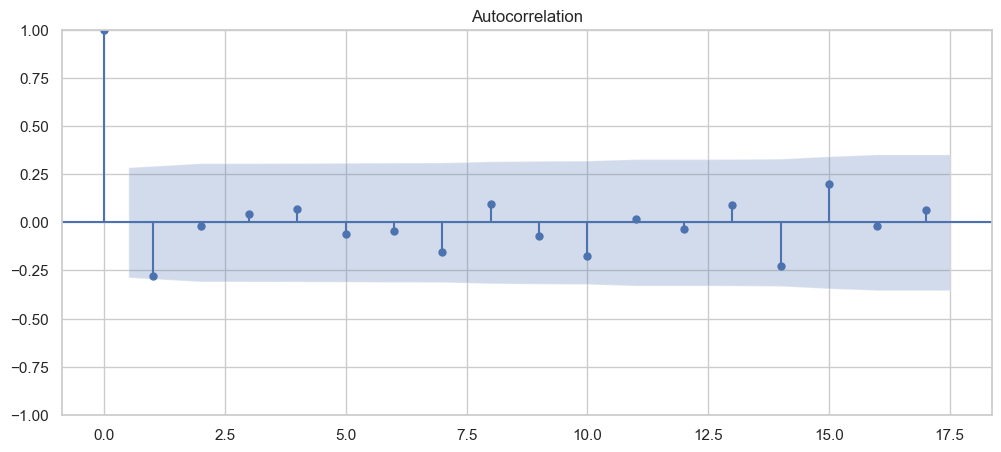

In [49]:
plot_acf(df.PD.diff(d).dropna(),);

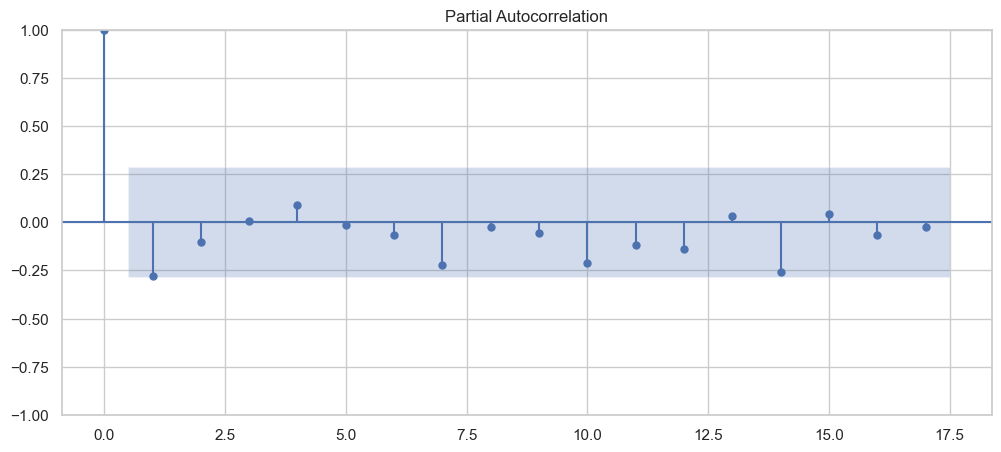

In [50]:
plot_pacf(df.PD.diff(d).dropna(),);

In [ ]:
target_col = 'PD'
exog_cols = ['CPI', 'GDP', 'EUR6M', 'U']
# StatsForecast DataFrame
sf_df = pd.DataFrame({
    'unique_id': 'PD', 'ds': df.month_end.values, 'y': df[target_col].values
})
for col in exog_cols:
    sf_df[col] = df[col].values

In [53]:
model = AutoARIMA(
    d=1,
    max_p=4,
    max_q=4,
    max_P=2,
    max_Q=2,
    start_p=1,
    start_q=1,
    max_order=12,
    season_length=4,
    stationary=True,
)
sf = StatsForecast(models=[model], freq='QE', n_jobs=-1)
sf.fit(df=sf_df)
arima_string(sf.fitted_[0,0].model_)
# result=sf.fitted_[0,0].model_

'ARIMA(1,0,0) with non-zero mean'

In [45]:
result

{'coef': {'ar1': np.float64(0.7983682272313959),
  'intercept': np.float64(1.9663839386115398)},
 'sigma2': np.float64(0.4535044090538886),
 'var_coef': array([[0.00704112, 0.0012111 ],
        [0.0012111 , 0.18721543]]),
 'mask': array([ True,  True]),
 'loglik': np.float64(-48.61682817454002),
 'aic': np.float64(103.23365634908004),
 'arma': (1, 0, 0, 0, 1, 0, 0),
 'residuals': array([ 0.6390729 , -0.66731888,  0.86505253,  0.2307658 ,  0.7164584 ,
        -0.7995501 ,  1.12287975,  0.09822682,  0.67236993, -0.07508416,
         0.71149912,  0.28138251,  0.83360749, -0.60177369,  0.94538157,
         0.90872891, -3.29629867, -0.29142079, -0.32063201, -0.31390839,
        -0.13807676, -0.32873811, -0.17054523,  0.4753995 , -0.32342899,
         0.15957743, -0.22845787,  0.72485252,  0.10894796, -0.30170683,
         0.01032059, -0.28214909,  0.06023269, -0.17165761, -0.152642  ,
        -0.19113972, -0.30561808, -0.20946049, -0.18071712, -0.19087979,
        -0.20011152, -0.20423201, 

In [ ]:
SARIMAX

In [63]:
# Uvoz validacijskih podatkov
valid = pd.read_csv('validacija.csv', sep=None, engine='python')
valid.PD = valid.PD.str.replace(',', '.')
valid.PD = valid.PD.astype(float)

print(f"Velikost: {valid.shape}")
print(f"\nImena stolpcev:")
print(valid.columns.tolist())
print(f"\nPrvih 5 vrstic:")
display(valid.head())
print(f"\nManjkajoče vrednosti:")
print(valid.isnull().sum())

Velikost: (6304, 11)

Imena stolpcev:
['CLIENT_ID', 'DEF_CLIENT', 'Registration_Y', 'SKD', 'LEGAL_SIZE', 'Assets', 'Equity', 'Sale', 'Profit', 'PD', 'PD_RATING_ORD']

Prvih 5 vrstic:


,CLIENT_ID,DEF_CLIENT,Registration_Y,SKD,LEGAL_SIZE,Assets,Equity,Sale,Profit,PD,PD_RATING_ORD
0,1,0,2009,M 69,micro,57839,18547,180684,2309,0.005399,4 (BBB)
1,2,0,2008,P 85,micro,169148,52599,207152,9230,0.005311,4 (BBB)
2,3,0,1996,M 72,micro,1209867,1120900,1986869,81005,0.006683,4 (BBB)
3,4,0,1999,F 43,micro,275534,102615,353797,3470,0.008412,5 (BB)
4,5,0,1992,G 46,micro,1373707,1224158,639589,16607,0.001891,2 (AA)



Manjkajoče vrednosti:
CLIENT_ID         0
DEF_CLIENT        0
Registration_Y    0
SKD               0
LEGAL_SIZE        0
Assets            0
Equity            0
Sale              0
Profit            0
PD                0
PD_RATING_ORD     0
dtype: int64


=== PORAZDELITEV NEPLAČNIKOV ===


DEF_CLIENT
0    6219
1      85
Name: count, dtype: int64


Delež neplačnikov: 1.35%

=== POVPREČNA PD PO BONITETNIH RAZREDIH ===


,Stevilo_komitentov,Dejanskih_neplačnikov,Stopnja_neplačil,Povprecna_PD
PD_RATING_ORD,,,,
2 (AA),1075,7,0.0065,0.0019
3 (A),1228,8,0.0065,0.0032
4 (BBB),1163,15,0.0129,0.0058
5 (BB),1157,14,0.0121,0.0110
6 (B),861,12,0.0139,0.0216
7 (CCC),635,18,0.0283,0.0431
8 (CC),131,5,0.0382,0.0923
9 (C),34,4,0.1176,0.1682
9x (D),20,2,0.1000,0.3331


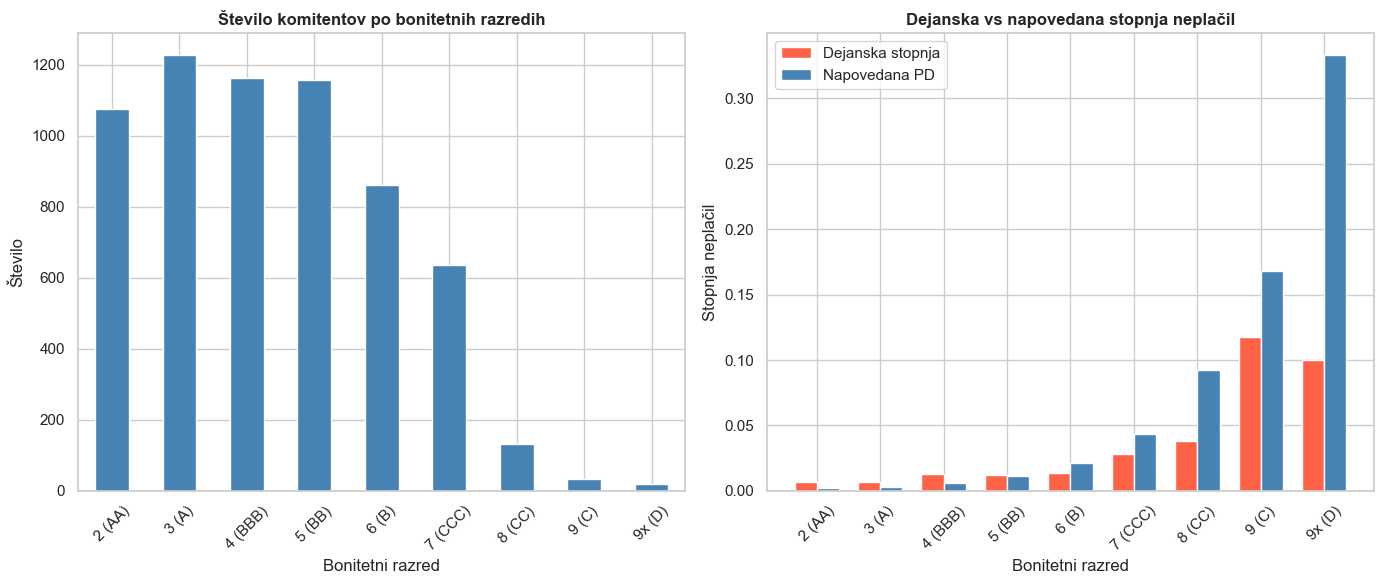

In [67]:
# Osnovna statistika
print("=== PORAZDELITEV NEPLAČNIKOV ===")
display(valid['DEF_CLIENT'].value_counts())
print(f"\nDelež neplačnikov: {valid['DEF_CLIENT'].mean()*100:.2f}%")

# Porazdelitev PD po razredih
print("\n=== POVPREČNA PD PO BONITETNIH RAZREDIH ===")
razredi = valid.groupby('PD_RATING_ORD').agg(
    Stevilo_komitentov=('CLIENT_ID', 'count'),
    Dejanskih_neplačnikov=('DEF_CLIENT', 'sum'),
    Stopnja_neplačil=('DEF_CLIENT', 'mean'),
    Povprecna_PD=('PD', 'mean')
).round(4)
display(razredi)

# Graf: Dejanska stopnja neplačil vs napovedana PD po razredih
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Graf 1: Število komitentov po razredih
razredi['Stevilo_komitentov'].plot(kind='bar', ax=axes[0], 
                                    color='steelblue', edgecolor='white')
axes[0].set_title('Število komitentov po bonitetnih razredih', fontweight='bold')
axes[0].set_xlabel('Bonitetni razred')
axes[0].set_ylabel('Število')
axes[0].tick_params(axis='x', rotation=45)

# Graf 2: Dejanska vs napovedana stopnja neplačil
x = range(len(razredi))
width = 0.35
axes[1].bar([i - width/2 for i in x], razredi['Stopnja_neplačil'], 
            width, label='Dejanska stopnja', color='tomato', edgecolor='white')
axes[1].bar([i + width/2 for i in x], razredi['Povprecna_PD'], 
            width, label='Napovedana PD', color='steelblue', edgecolor='white')
axes[1].set_title('Dejanska vs napovedana stopnja neplačil', fontweight='bold')
axes[1].set_xlabel('Bonitetni razred')
axes[1].set_ylabel('Stopnja neplačil')
axes[1].set_xticks(list(x))
axes[1].set_xticklabels(razredi.index, rotation=45)
axes[1].legend()

plt.tight_layout()
plt.savefig('bonitetni_razredi.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# Popravek PD stolpca - zamenjava vejice s piko in pretvorba v številko
valid['PD'] = valid['PD'].astype(str).str.replace(',', '.').astype(float)

print("PD stolpec popravljen")
print(f"Tip stolpca: {valid['PD'].dtype}")
print(f"Primer vrednosti: {valid['PD'].head()}")

# Ponovna analiza po razredih
razredi = valid.groupby('PD_RATING_ORD').agg(
    Stevilo=('CLIENT_ID', 'count'),
    Neplačniki=('DEF_CLIENT', 'sum'),
    Stopnja_neplačil=('DEF_CLIENT', 'mean'),
    Povprecna_PD=('PD', 'mean')
).round(4)

print("\n=== POVPREČNA PD PO BONITETNIH RAZREDIH ===")
display(razredi)


=== POVPREČNA PD PO BONITETNIH RAZREDIH ===


,Stevilo,Neplačniki,Stopnja_neplačil,Povprecna_PD
PD_RATING_ORD,,,,
2 (AA),1075,7,0.0065,0.0019
3 (A),1228,8,0.0065,0.0032
4 (BBB),1163,15,0.0129,0.0058
5 (BB),1157,14,0.0121,0.0110
6 (B),861,12,0.0139,0.0216
7 (CCC),635,18,0.0283,0.0431
8 (CC),131,5,0.0382,0.0923
9 (C),34,4,0.1176,0.1682
9x (D),20,2,0.1000,0.3331


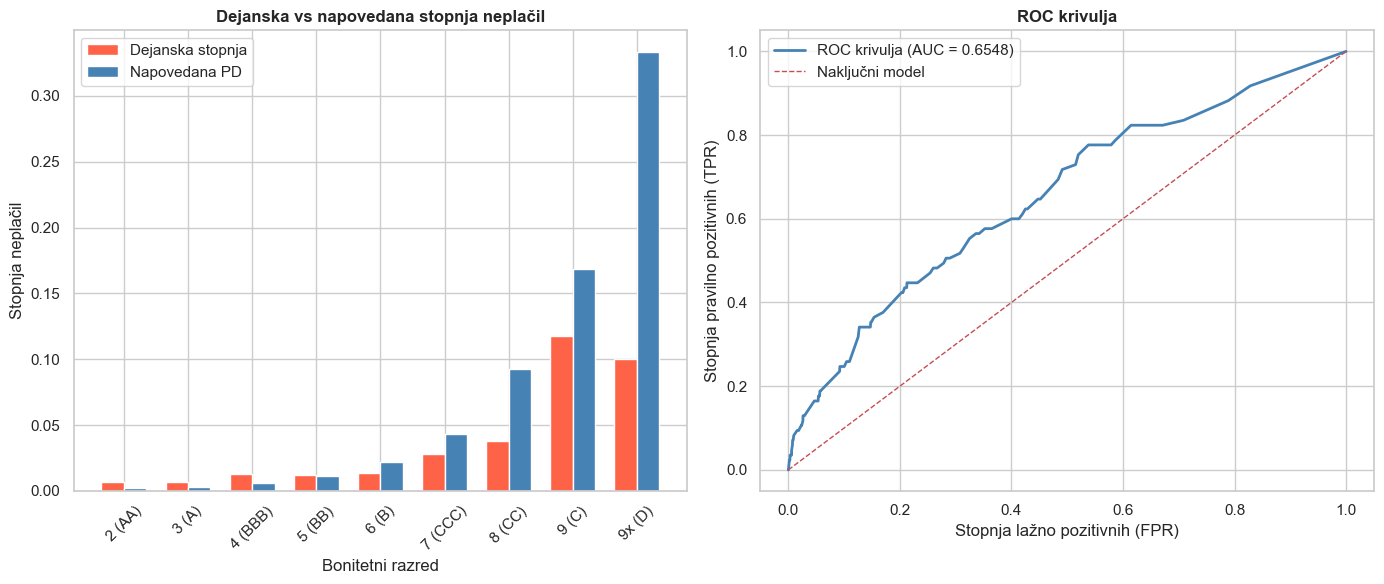

AUC: 0.6548
Gini koeficient: 0.3096
Razlaga: Slaba ločljivost (Gini<0.4)


In [40]:
from sklearn.metrics import roc_auc_score, roc_curve

# Uvoz podatkov
valid = pd.read_csv('validacija.csv', sep=None, engine='python')
valid['PD'] = valid['PD'].astype(str).str.replace(',', '.').astype(float)

# Izračun razredov
razredi = valid.groupby('PD_RATING_ORD').agg(
    Stevilo=('CLIENT_ID', 'count'),
    Neplačniki=('DEF_CLIENT', 'sum'),
    Stopnja_neplačil=('DEF_CLIENT', 'mean'),
    Povprecna_PD=('PD', 'mean')
).round(4)

# Graf 1: Dejanska vs napovedana PD po razredih
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

x = range(len(razredi))
width = 0.35
axes[0].bar([i - width/2 for i in x], razredi['Stopnja_neplačil'],
            width, label='Dejanska stopnja', color='tomato', edgecolor='white')
axes[0].bar([i + width/2 for i in x], razredi['Povprecna_PD'],
            width, label='Napovedana PD', color='steelblue', edgecolor='white')
axes[0].set_title('Dejanska vs napovedana stopnja neplačil', fontweight='bold')
axes[0].set_xlabel('Bonitetni razred')
axes[0].set_ylabel('Stopnja neplačil')
axes[0].set_xticks(list(x))
axes[0].set_xticklabels(razredi.index, rotation=45)
axes[0].legend()

# Graf 2: ROC krivulja
fpr, tpr, _ = roc_curve(valid['DEF_CLIENT'], valid['PD'])
auc = roc_auc_score(valid['DEF_CLIENT'], valid['PD'])
axes[1].plot(fpr, tpr, color='steelblue', linewidth=2,
             label=f'ROC krivulja (AUC = {auc:.4f})')
axes[1].plot([0,1], [0,1], 'r--', linewidth=1, label='Naključni model')
axes[1].set_title('ROC krivulja', fontweight='bold')
axes[1].set_xlabel('Stopnja lažno pozitivnih (FPR)')
axes[1].set_ylabel('Stopnja pravilno pozitivnih (TPR)')
axes[1].legend()

plt.tight_layout()
plt.savefig('validacija_model.png', dpi=150, bbox_inches='tight')
plt.show()

# Gini koeficient
gini = 2 * auc - 1
print(f"AUC: {auc:.4f}")
print(f"Gini koeficient: {gini:.4f}")
print(f"Razlaga: {'Dobra ločljivost (Gini>0.6)' if gini > 0.6 else 'Zmerna ločljivost (Gini 0.4-0.6)' if gini > 0.4 else 'Slaba ločljivost (Gini<0.4)'}")

=== KS TEST (ločljivost) ===
KS statistika: 0.2384
p-vrednost: 0.000112
Razlaga: Model ločuje (p<0.05)


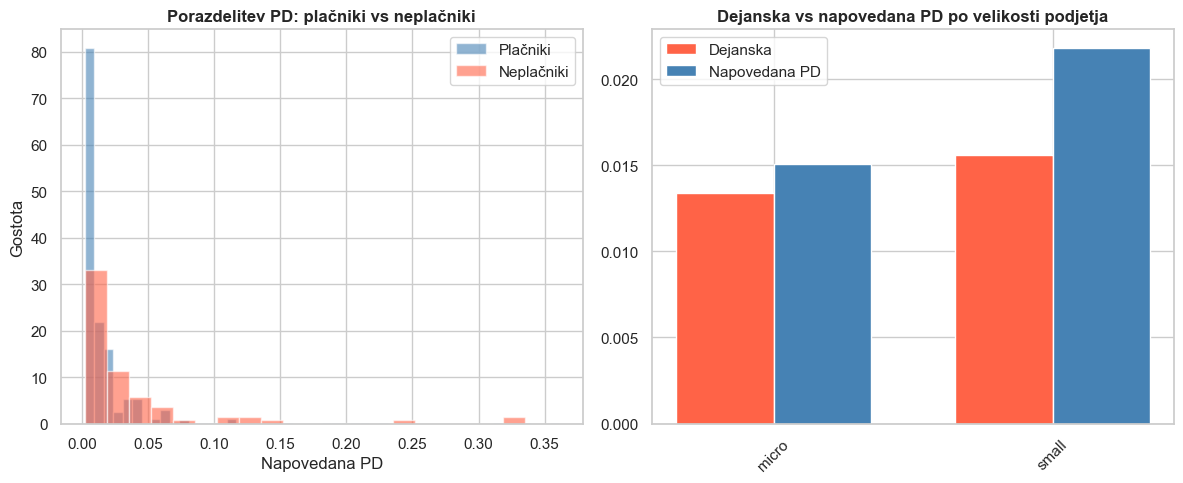


=== ANALIZA PO VELIKOSTI PODJETJA ===
            Stopnja_neplačil  Povprecna_PD  Stevilo
LEGAL_SIZE                                         
micro                 0.0134        0.0151     6176
small                 0.0156        0.0218      128


In [41]:
from scipy.stats import ks_2samp

# KS test - ločljivost med plačniki in neplačniki
pd_placniki = valid[valid['DEF_CLIENT']==0]['PD']
pd_neplačniki = valid[valid['DEF_CLIENT']==1]['PD']

ks_stat, ks_p = ks_2samp(pd_placniki, pd_neplačniki)
print("=== KS TEST (ločljivost) ===")
print(f"KS statistika: {ks_stat:.4f}")
print(f"p-vrednost: {ks_p:.6f}")
print(f"Razlaga: {'Model ločuje (p<0.05)' if ks_p < 0.05 else 'Model ne ločuje (p>0.05)'}")

# Porazdelitev PD za plačnike vs neplačnike
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.hist(pd_placniki, bins=50, alpha=0.6, color='steelblue', label='Plačniki', density=True)
plt.hist(pd_neplačniki, bins=20, alpha=0.6, color='tomato', label='Neplačniki', density=True)
plt.title('Porazdelitev PD: plačniki vs neplačniki', fontweight='bold')
plt.xlabel('Napovedana PD')
plt.ylabel('Gostota')
plt.legend()

# Analiza po velikosti podjetja
plt.subplot(1, 2, 2)
velikost_analiza = valid.groupby('LEGAL_SIZE').agg(
    Stopnja_neplačil=('DEF_CLIENT', 'mean'),
    Povprecna_PD=('PD', 'mean'),
    Stevilo=('CLIENT_ID', 'count')
).round(4)

x = range(len(velikost_analiza))
width = 0.35
plt.bar([i-width/2 for i in x], velikost_analiza['Stopnja_neplačil'],
        width, label='Dejanska', color='tomato', edgecolor='white')
plt.bar([i+width/2 for i in x], velikost_analiza['Povprecna_PD'],
        width, label='Napovedana PD', color='steelblue', edgecolor='white')
plt.title('Dejanska vs napovedana PD po velikosti podjetja', fontweight='bold')
plt.xticks(list(x), velikost_analiza.index, rotation=45)
plt.legend()

plt.tight_layout()
plt.savefig('ks_test_segmenti.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n=== ANALIZA PO VELIKOSTI PODJETJA ===")
print(velikost_analiza)

In [ ]:
mnenje_3_3 = """
VALIDACIJSKO MNENJE - 3.3 KVALITATIVNI PREGLED
================================================

PODATKI: 6304 komitentov, 1.35% neplačnikov, 9 bonitetnih razredov

1. ALI MODEL LOČUJE NEPLAČNIKE OD PLAČNIKOV?
---------------------------------------------
DA - model statistično ločuje neplačnike od plačnikov:
- KS statistika = 0.2384 (p=0.000112 < 0.05)
- Stopnja neplačil raste z slabšim bonitetnim razredom:
  AA: 0.65% → A: 0.65% → BBB: 1.29% → CCC: 2.83% → C: 11.76%
- Monoton trend je prisoten

AMPAK: Gini koeficient = 0.31 (AUC=0.65) kaže SLABO ločljivost
- Sprejemljiva meja v bančništvu je Gini > 0.40
- Model je na meji sprejemljivosti

2. ALI NAPOVEDANA VERJETNOST USTREZA DEJANSKEMU STANJU?
---------------------------------------------------------
NE - prisotna sistematična napaka kalibracije:
- Pri dobrih razredih (AA, A): model podcenjuje tveganje
  AA: dejanska 0.65% vs napovedana 0.19%
- Pri slabih razredih (C, D): model precenjuje tveganje  
  C: dejanska 11.76% vs napovedana 16.82%
- Model ni dobro kalibriran → potrebna rekalibracija!

3. ALI MODEL OHRANJA NAPOVEDNO MOČ V RAZLIČNIH SKUPINAH?
----------------------------------------------------------
Analiza po velikosti podjetja:
- Mikro podjetja: dejanska 1.34% vs napovedana 1.51% (blizu)
- Mala podjetja: dejanska 1.56% vs napovedana 2.18% (precenjena)
- Samo 2 segmenta - premalo za celovito analizo segmentov
Priporočamo analizo po SKD dejavnosti in letu registracije

4. KAJ BI ŠE POGLEDALI PRI MODELU?
-------------------------------------
- PSI test (Population Stability Index): ali se je populacija 
  komitentov spremenila od razvoja modela?
- Backtesting: primerjava napovedi z dejanskimi neplačili 
  skozi več let
- Analiza po SKD dejavnosti: ali model deluje enako v vseh 
  panogah?
- Analiza manjšinskih skupin: ali model diskriminira po spolu,
  starosti ali lokaciji?
- Preveriti ali so vhodne spremenljivke stabilne skozi čas
- Primerjava z benchmark modelom (npr. samo logistična regresija)

5. SKUPNA OCENA MODELA
-----------------------
OCENA: S PRIDRŽKOM

Pozitivno:
- Model statistično ločuje neplačnike od plačnikov (KS test)
- Monoton trend stopnje neplačil po razredih
- Nizka stopnja neplačil (1.35%) - model je konzervativen

Negativno:
- Gini = 0.31 - pod sprejemljivo mejo 0.40 za kreditne modele
- Sistematična napaka kalibracije - PD ni dobro umerjena
- Napovedana PD precenjena pri slabih razredih

PRIPOROČILA:
→ Nujna rekalibracija modela (Platt scaling ali isotonic regression)
→ Pregled metodologije razvoja modela
→ Povečati vzorec neplačnikov za boljše učenje
→ Naslednja validacija v 6 mesecih (ne 12)
→ Model pogojno primeren za uporabo - z rednim monitoringom
"""

print(mnenje_3_3)


VALIDACIJSKO MNENJE - 3.3 KVALITATIVNI PREGLED

PODATKI: 6304 komitentov, 1.35% neplačnikov, 9 bonitetnih razredov

1. ALI MODEL LOČUJE NEPLAČNIKE OD PLAČNIKOV?
---------------------------------------------
DA - model statistično ločuje neplačnike od plačnikov:
- KS statistika = 0.2384 (p=0.000112 < 0.05)
- Stopnja neplačil raste z slabšim bonitetnim razredom:
  AA: 0.65% → A: 0.65% → BBB: 1.29% → CCC: 2.83% → C: 11.76%
- Monoton trend je prisoten

AMPAK: Gini koeficient = 0.31 (AUC=0.65) kaže SLABO ločljivost
- Sprejemljiva meja v bančništvu je Gini > 0.40
- Model je na meji sprejemljivosti

2. ALI NAPOVEDANA VERJETNOST USTREZA DEJANSKEMU STANJU?
---------------------------------------------------------
NE - prisotna sistematična napaka kalibracije:
- Pri dobrih razredih (AA, A): model podcenjuje tveganje
  AA: dejanska 0.65% vs napovedana 0.19%
- Pri slabih razredih (C, D): model precenjuje tveganje  
  C: dejanska 11.76% vs napovedana 16.82%
- Model ni dobro kalibriran → potrebna r